**Programmer: python_scripts (Abhijith Warrier)**

**🔬 Python Code Lab — List vs Set Lookup: How Big Is the Difference?**

Python lists and sets both support membership checks using the `in` operator, but their underlying data structures work differently.

This experiment benchmarks membership checks across increasing collection sizes using `timeit` to understand how lookup performance changes.

---

## ❓ Question

How much faster is a set compared to a list when checking whether an element exists?

Both collections support the `in` operator:

- `value in my_list`
- `value in my_set`

However, lists generally perform a sequential search, while sets use hash-based lookups.

We'll measure how these differences affect performance as collections grow from hundreds to hundreds of thousands of elements.

---

## 🧪 Experiment Setup

We'll use Python's built-in `timeit` module to measure membership-check execution times.

Our experiments will compare:

- **List Lookup:** Membership checks using a Python list.
- **Set Lookup:** Membership checks using a Python set.
- **Collection Sizes:** Increasing from 100 to 100,000 elements.
- **Lookup Scenarios:** Searching for existing and missing elements.

To make the comparison meaningful, both collections will contain the same integer values.

We'll measure lookup operations independently of collection creation so that we're comparing membership-check performance rather than construction time.

In [1]:
# Import timeit for benchmarking execution time
import timeit

# Define collection sizes for benchmarking
collection_sizes = [100, 1_000, 10_000, 100_000]

# Number of membership checks per benchmark
iterations = 10_000

# Number of benchmark repetitions
repeats = 5

---

## ▶️ Experiment 1 — Creating Lists and Sets

First, we'll create a list and a set containing identical integer values.

For each collection size, the values will range from `0` to `size - 1`.

This ensures both collections contain the same elements, allowing us to compare their membership-check behaviour.

We'll begin with a small example before running the complete benchmark.

In [2]:
# Create a sample list containing 1,000 integers
sample_list = list(range(1_000))

# Create a set containing the same integers
sample_set = set(sample_list)

# Check whether an existing element is present
target = 999

print("List lookup:", target in sample_list)
print("Set lookup:", target in sample_set)

# Display collection sizes
print("\nList size:", len(sample_list))
print("Set size:", len(sample_set))

List lookup: True
Set lookup: True

List size: 1000
Set size: 1000


---

## ▶️ Experiment 2 — Measuring Membership Checks

We'll create a reusable benchmarking function using `timeit.repeat()`.

The function measures how long a membership check takes across multiple repetitions.

We'll use the minimum recorded time to represent the fastest observed execution under the benchmark conditions.

Dividing that time by the number of iterations gives us the average time per lookup within the selected repetition.

Results will be displayed in microseconds (µs).

In [3]:
def benchmark_lookup(collection, target):
    """Measure membership-check execution time."""

    # Define the membership operation
    def lookup():
        return target in collection

    # Repeat the benchmark multiple times
    timings = timeit.repeat(
        lookup,
        number=iterations,
        repeat=repeats,
    )

    # Select the fastest observed repetition
    best_time = min(timings)

    # Convert seconds per lookup into microseconds
    return (best_time / iterations) * 1_000_000

---

## ▶️ Experiment 3 — Searching for an Existing Element

Our first benchmark checks for an element that exists at the end of each list.

For a list, finding the final element generally requires examining all preceding elements.

For a set, membership checks use hash-based lookup, which typically provides approximately constant-time performance.

We'll repeat the experiment across increasing collection sizes and compare the measured execution times.

In [4]:
# Store benchmark results
existing_results = []

for size in collection_sizes:
    # Create collections with identical values
    numbers_list = list(range(size))
    numbers_set = set(numbers_list)

    # Search for the last element
    target = size - 1

    # Measure lookup times
    list_time = benchmark_lookup(numbers_list, target)
    set_time = benchmark_lookup(numbers_set, target)

    # Calculate the relative speed difference
    speedup = list_time / set_time

    existing_results.append(
        (size, list_time, set_time, speedup)
    )

print("Existing Element Lookup\n")

print(
    f"{'Size':>10} "
    f"{'List (µs)':>15} "
    f"{'Set (µs)':>15} "
    f"{'Speedup':>12}"
)

print("-" * 56)

for size, list_time, set_time, speedup in existing_results:
    print(
        f"{size:>10,} "
        f"{list_time:>15.4f} "
        f"{set_time:>15.4f} "
        f"{speedup:>11.2f}x"
    )

Existing Element Lookup

      Size       List (µs)        Set (µs)      Speedup
--------------------------------------------------------
       100          0.3635          0.0259       14.04x
     1,000          3.3098          0.0308      107.58x
    10,000         33.3381          0.0308     1082.99x
   100,000        340.6156          0.0316    10793.18x


---

## ▶️ Experiment 4 — Searching for a Missing Element

What happens when the element doesn't exist?

For a list, Python must examine the entire collection before concluding that the value is absent.

For a set, Python can usually determine membership using its hash table without scanning every element.

We'll repeat the same benchmark using a value that doesn't exist in either collection.

In [5]:
# Store missing-element benchmark results
missing_results = []

for size in collection_sizes:
    # Create collections with identical values
    numbers_list = list(range(size))
    numbers_set = set(numbers_list)

    # Select a value outside the collection
    target = -1

    # Measure lookup times
    list_time = benchmark_lookup(numbers_list, target)
    set_time = benchmark_lookup(numbers_set, target)

    # Calculate the relative speed difference
    speedup = list_time / set_time

    missing_results.append(
        (size, list_time, set_time, speedup)
    )

print("Missing Element Lookup\n")

print(
    f"{'Size':>10} "
    f"{'List (µs)':>15} "
    f"{'Set (µs)':>15} "
    f"{'Speedup':>12}"
)

print("-" * 56)

for size, list_time, set_time, speedup in missing_results:
    print(
        f"{size:>10,} "
        f"{list_time:>15.4f} "
        f"{set_time:>15.4f} "
        f"{speedup:>11.2f}x"
    )

Missing Element Lookup

      Size       List (µs)        Set (µs)      Speedup
--------------------------------------------------------
       100          0.3486          0.0262       13.31x
     1,000          3.2643          0.0258      126.65x
    10,000         33.4974          0.0258     1297.09x
   100,000        339.8287          0.0274    12421.41x


---

## 📊 Results — Comparing Lookup Performance

Let's summarise both experiments in a single table.

We'll compare the measured execution times for:

1. Existing elements located at the end of each list.
2. Missing elements that don't exist in either collection.

The speedup represents how many times faster the measured set lookup was compared with the corresponding list lookup.

A speedup greater than `1x` means the set was faster.

The measurements are generated when the notebook runs, so results may differ across machines and Python versions.

In [6]:
print("LIST VS SET LOOKUP — BENCHMARK RESULTS\n")

print(
    f"{'Size':>10} "
    f"{'Scenario':>12} "
    f"{'List (µs)':>15} "
    f"{'Set (µs)':>15} "
    f"{'Speedup':>12}"
)

print("-" * 70)

# Display results from both experiments
for scenario, results in [
    ("Existing", existing_results),
    ("Missing", missing_results),
]:
    for size, list_time, set_time, speedup in results:
        print(
            f"{size:>10,} "
            f"{scenario:>12} "
            f"{list_time:>15.4f} "
            f"{set_time:>15.4f} "
            f"{speedup:>11.2f}x"
        )

LIST VS SET LOOKUP — BENCHMARK RESULTS

      Size     Scenario       List (µs)        Set (µs)      Speedup
----------------------------------------------------------------------
       100     Existing          0.3635          0.0259       14.04x
     1,000     Existing          3.3098          0.0308      107.58x
    10,000     Existing         33.3381          0.0308     1082.99x
   100,000     Existing        340.6156          0.0316    10793.18x
       100      Missing          0.3486          0.0262       13.31x
     1,000      Missing          3.2643          0.0258      126.65x
    10,000      Missing         33.4974          0.0258     1297.09x
   100,000      Missing        339.8287          0.0274    12421.41x


---

## 📈 Visualising Lookup Performance

Tables provide exact measurements, but a chart makes performance trends easier to understand.

We'll visualise how lookup times change as the number of elements increases.

Because list and set lookup times may differ substantially, we'll use a logarithmic scale for the execution-time axis.

This allows us to compare both collections without losing visibility of the smaller measurements.

Matplotlib is building the font cache; this may take a moment.


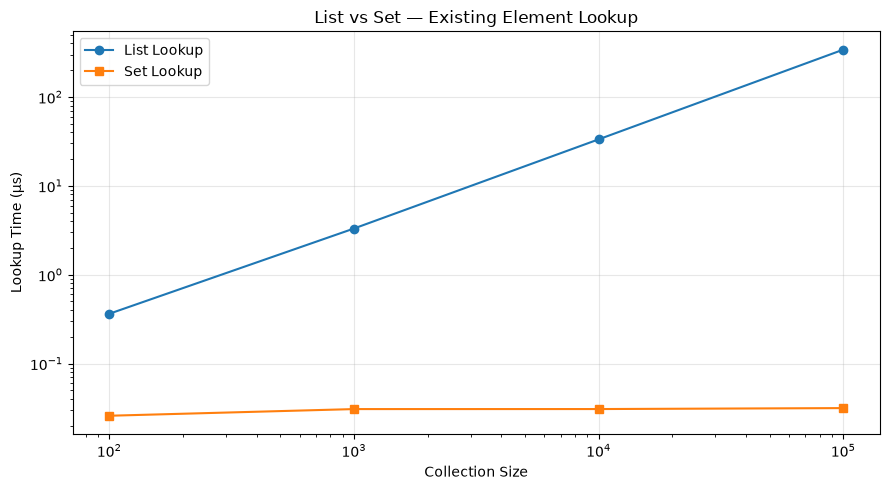

In [8]:
# Import matplotlib for visualizing benchmark results
import matplotlib.pyplot as plt

# Extract collection sizes and measured timings
sizes = [result[0] for result in existing_results]

list_times = [result[1] for result in existing_results]
set_times = [result[2] for result in existing_results]

# Create the performance comparison chart
plt.figure(figsize=(9, 5))

plt.plot(
    sizes,
    list_times,
    marker="o",
    label="List Lookup",
)

plt.plot(
    sizes,
    set_times,
    marker="s",
    label="Set Lookup",
)

# Configure the chart
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Collection Size")
plt.ylabel("Lookup Time (µs)")

plt.title("List vs Set — Existing Element Lookup")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 🔍 What's Happening?

The performance difference comes from how lists and sets organise their elements.

### List Lookup — O(n)

A Python list stores elements in an ordered sequence.

When checking membership using `in`, Python generally compares elements sequentially until it finds a match.

For example:

`10 in [2, 4, 6, 8, 10]`

Python may need to examine multiple elements before finding the target.

As the list grows, the number of comparisons can increase.

- **Best Case:** O(1) — the element is found immediately.
- **Average Case:** O(n) — multiple elements are examined.
- **Worst Case:** O(n) — the element is last or missing.

### Set Lookup — O(1) Average

A Python set uses a hash table.

Instead of searching sequentially, Python calculates the element's hash and uses it to locate the relevant position in the table.

This generally allows membership checks to remain fast even as the collection grows.

- **Average Case:** O(1)
- **Worst Case:** O(n), such as under pathological hash collisions.

However, sets require hashable elements and do not provide the same indexing or ordering behaviour as lists.

---

## 💡 Key Findings

- List membership checks generally become slower as collection sizes increase, particularly when searching for elements near the end or for missing values.
- Set membership checks typically remain much faster for large collections because they use hash-based lookup.
- List lookup has O(n) average time complexity, while set lookup has O(1) average time complexity.
- The difference becomes more noticeable when membership checks are performed repeatedly against large collections.
- Sets are useful for frequent membership checks, but lists remain appropriate when ordered sequences, indexing, or duplicate values are required.
- Benchmark results depend on the Python version, hardware, input data, and measurement conditions.

---

## 🧾 Conclusion

For repeated membership checks against large collections, Python sets generally provide a significant performance advantage over lists.

Lists perform sequential searches, so lookup time can increase with collection size. Sets use hash tables, allowing average membership checks to remain approximately constant-time.

However, choosing between a list and a set should depend on more than lookup speed. Lists support indexing and duplicate elements, while sets provide uniqueness and efficient membership testing.

The important lesson is that **the right data structure depends on the operations your application performs most frequently**.

Rather than assuming one approach is always better, benchmark the workload that matters to your application.

---